In [1]:
# silence warnings
import warnings

warnings.filterwarnings("ignore")

# operating system
import os

# time calculation to track some processes

# numeric and matrix operations
import pandas as pd

# loading ploting libraries
import matplotlib.pyplot as plt

%matplotlib inline

# python core library for machine learning and data science
import sklearn
from sklearn import set_config

set_config(transform_output="pandas")

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.preprocessing import RobustScaler
from sklearn.impute import KNNImputer
from sklearn.cluster import KMeans

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
DATA_PATH = "/content/drive/MyDrive/Portfolio_DataScience/clustering_bank_socioeconomico/datasets"
PATH_TRANSACTIONS = os.path.join(DATA_PATH, "bank_transactions.csv")

In [4]:
# El CSV viene con encoding latin-1 (no UTF-8), habitual en datasets de origen indio/no anglosajón.
# Sin este parámetro, pd.read_csv lanza UnicodeDecodeError.
df = pd.read_csv(PATH_TRANSACTIONS, encoding='latin-1')

#EDA

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048567 entries, 0 to 1048566
Data columns (total 9 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   TransactionID            1048567 non-null  object 
 1   CustomerID               1048567 non-null  object 
 2   CustomerDOB              1045170 non-null  object 
 3   CustGender               1047467 non-null  object 
 4   CustLocation             1048416 non-null  object 
 5   CustAccountBalance       1046198 non-null  float64
 6   TransactionDate          1048567 non-null  object 
 7   TransactionTime          1048567 non-null  int64  
 8   TransactionAmount (INR)  1048567 non-null  float64
dtypes: float64(2), int64(1), object(6)
memory usage: 72.0+ MB


In [6]:
df.head()

,TransactionID,CustomerID,CustomerDOB,CustGender,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount (INR)
0,T1,C5841053,10/1/94,F,JAMSHEDPUR,17819.05,2/8/16,143207,25.0
1,T2,C2142763,4/4/57,M,JHAJJAR,2270.69,2/8/16,141858,27999.0
2,T3,C4417068,26/11/96,F,MUMBAI,17874.44,2/8/16,142712,459.0
3,T4,C5342380,14/9/73,F,MUMBAI,866503.21,2/8/16,142714,2060.0
4,T5,C9031234,24/3/88,F,NAVI MUMBAI,6714.43,2/8/16,181156,1762.5


In [7]:
df.describe()

,CustAccountBalance,TransactionTime,TransactionAmount (INR)
count,1.046198e+06,1.048567e+06,1.048567e+06
mean,1.154035e+05,1.570875e+05,1.574335e+03
std,8.464854e+05,5.126185e+04,6.574743e+03
min,0.000000e+00,0.000000e+00,0.000000e+00
25%,4.721760e+03,1.240300e+05,1.610000e+02
50%,1.679218e+04,1.642260e+05,4.590300e+02
75%,5.765736e+04,2.000100e+05,1.200000e+03
max,1.150355e+08,2.359590e+05,1.560035e+06


In [8]:
# ¿Cuántos registros tienen saldo cero, y qué pinta tienen esas filas?
print("Balance = 0:", (df['CustAccountBalance'] == 0).sum())
df[df['CustAccountBalance'] == 0].head()

Balance = 0: 2711


,TransactionID,CustomerID,CustomerDOB,CustGender,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount (INR)
663,T664,C1189836,28/12/76,M,AHMEDABAD,0.0,21/10/16,204450,13259.48
982,T983,C4865613,1/1/1800,F,CHENNAI,0.0,21/10/16,204421,1500.00
2051,T2052,C6286520,6/12/90,M,CHANDIGARH,0.0,21/10/16,200759,118.00
2836,T2837,C1583719,3/10/94,F,GURGAON,0.0,21/10/16,153121,500.00
3270,T3271,C3183741,3/10/94,F,GURGAON,0.0,21/10/16,152002,673.00


In [9]:
# ¿Cuántos registros tienen importe de transacción cero?
print("Amount = 0:", (df['TransactionAmount (INR)'] == 0).sum())
df[df['TransactionAmount (INR)'] == 0].head()

Amount = 0: 835


,TransactionID,CustomerID,CustomerDOB,CustGender,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount (INR)
384,T385,C6117158,25/9/89,M,BANGALORE,128.84,21/10/16,74817,0.0
2498,T2499,C9074213,10/6/88,M,BANGALORE,15834.56,21/10/16,154219,0.0
2623,T2624,C7930692,16/7/93,M,HYDERABAD,5795.30,21/10/16,152742,0.0
2672,T2673,C4397046,13/1/97,M,MUMBAI,185401.34,21/10/16,30017,0.0
4083,T4084,C4227711,3/12/91,M,NEW DELHI,11846.77,22/9/16,70059,0.0


In [10]:
df[df['TransactionAmount (INR)'] == 0]['CustLocation'].value_counts().head(10)

,count
CustLocation,
NEW DELHI,94
MUMBAI,83
DELHI,79
BANGALORE,76
GURGAON,73
HYDERABAD,32
NOIDA,31
PUNE,14
CHENNAI,13


In [11]:
df[df['TransactionAmount (INR)'] == 0]['TransactionDate'].value_counts().sort_index().head(10)

,count
TransactionDate,
1/8/16,14
1/9/16,42
10/8/16,35
10/9/16,18
11/8/16,29
11/9/16,6
12/8/16,20
12/9/16,16
13/8/16,28


In [12]:
df['CustLocation'].value_counts().head(10)

,count
CustLocation,
MUMBAI,103595
NEW DELHI,84928
BANGALORE,81555
GURGAON,73818
DELHI,71019
NOIDA,32784
CHENNAI,30009
PUNE,25851
HYDERABAD,23049


In [13]:
# Revisamos cuántos valores nulos hay por columna y qué peso representan
# sobre el total, para decidir más adelante cómo tratarlos en Data Cleaning.
nulos = df.isnull().sum()
porcentaje = (nulos / len(df) * 100).round(2)
pd.DataFrame({'nulos': nulos, 'porcentaje': porcentaje}).query('nulos > 0')

,nulos,porcentaje
CustomerDOB,3397,0.32
CustGender,1100,0.10
CustLocation,151,0.01
CustAccountBalance,2369,0.23


In [14]:
# Vemos si los nulos de las distintas columnas caen en las mismas filas
# o si son casos independientes, para decidir la estrategia de tratamiento en Data Cleaning.
filas_con_algun_nulo = df[df[['CustomerDOB', 'CustGender', 'CustLocation', 'CustAccountBalance']].isnull().any(axis=1)]
print("Filas con al menos un nulo:", len(filas_con_algun_nulo))
print("Suma de nulos por columna (si no hubiera solapamiento):", 3397 + 1100 + 151 + 2369)

Filas con al menos un nulo: 6953
Suma de nulos por columna (si no hubiera solapamiento): 7017


In [15]:
# Revisamos los valores únicos de género para detectar inconsistencias
# (mayúsculas/minúsculas distintas, valores inesperados, etc.)
df['CustGender'].value_counts(dropna=False)

,count
CustGender,
M,765530
F,281936
NaN,1100
T,1


In [16]:
# Miramos la fila completa con género 'T' para ver si hay algo más raro en ella
df[df['CustGender'] == 'T']

,TransactionID,CustomerID,CustomerDOB,CustGender,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount (INR)
959987,T959988,C3380368,1/1/1800,T,CHENNAI,50050.0,10/9/16,170731,32500.0


In [17]:
# Convertimos CustomerDOB a datetime para poder explorar el rango de fechas
# y detectar valores imposibles (ej. años como 1800, o fechas futuras).
df['CustomerDOB_parsed'] = pd.to_datetime(df['CustomerDOB'], format='%d/%m/%y', errors='coerce')
print(df['CustomerDOB_parsed'].min(), df['CustomerDOB_parsed'].max())

1969-01-01 00:00:00 2068-12-31 00:00:00


In [18]:
# Contamos cuántas fechas fueron parseadas como año 2000-2068 (probable error de pivote,
# ya que decidimos que ningún cliente real debería tener año de nacimiento posterior a 1968
# bajo esta corrección manual).
mal_parseadas = df[df['CustomerDOB_parsed'] > '1968-12-31']
print("Filas con fecha de nacimiento mal parseada (año futuro erróneo):", len(mal_parseadas))
mal_parseadas['CustomerDOB_parsed'].dt.year.value_counts().sort_index()

Filas con fecha de nacimiento mal parseada (año futuro erróneo): 987831


,count
CustomerDOB_parsed,
1969,5965
1970,7283
1971,7420
1972,9221
1973,9957
...,...
2064,3582
2065,3894
2066,4202


## Resumen EDA — Calidad de datos

**Estructura general**
- 1.048.567 transacciones, 884.265 clientes únicos.
- Media de ~1,19 transacciones por cliente; 83,7% de clientes con una única
  transacción. Esto descarta el uso de un marco RFM clásico (sin frecuencia
  ni recencia significativas) y orienta el proyecto hacia una segmentación
  de perfil socioeconómico (demografía + saldo + gasto puntual).
- Rango temporal: 1/8/2016 a 21/10/2016 (~2,5 meses).

**Valores en cero**
- `CustAccountBalance = 0`: 2.711 filas (0,26%). Posible situación real de
  negocio (cuenta a cero) → se mantendrán.
- `TransactionAmount (INR) = 0`: 835 filas (0,08%). Sin patrón por fecha ni
  ciudad (proporcional al volumen general) → ruido disperso, candidatas a
  eliminar en Data Cleaning.

**Valores nulos**
- `CustomerDOB`: 3.397 (0,32%) · `CustGender`: 1.100 (0,10%) ·
  `CustLocation`: 151 (0,01%) · `CustAccountBalance`: 2.369 (0,23%).
- Solapamiento mínimo entre columnas (6.953 filas con algún nulo frente a
  7.017 esperadas sin solapamiento) → nulos independientes, sin patrón de
  fallo sistemático de captura conjunta.

**CustGender**
- Valores: `M` (765.530), `F` (281.936), `NaN` (1.100), `T` (1).
- El caso `T` corresponde a una fila con `CustomerDOB = 1/1/1800`, fecha de
  nacimiento imposible → indicio de fila con datos corruptos, no una
  categoría de género legítima. Candidata a revisión/eliminación en Data
  Cleaning.

**CustomerDOB**
- Al parsear con formato `%d/%m/%y`, el rango resultante es 1969-01-01 a
  2068-12-31 → confirma el problema de pivote de año de 2 dígitos: los
  nacidos entre 1900-1968 se están interpretando como 2000-2068.
- Se establece 1968 como año de corte para la corrección manual del pivote
  en Data Cleaning.
- El caso de género `T` corresponde a una fila con `CustomerDOB = 1/1/1800`
  (fecha inválida, fuera de rango de 2 dígitos, quedó como NaT) → fila con
  datos corruptos, se revisará en Data Cleaning.

#DATA CLEANING

##Duplicados

In [19]:
df.duplicated().sum()

np.int64(0)

## Nulos

In [20]:
df.isnull().sum()

,0
TransactionID,0
CustomerID,0
CustomerDOB,3397
CustGender,1100
CustLocation,151
CustAccountBalance,2369
TransactionDate,0
TransactionTime,0
TransactionAmount (INR),0
CustomerDOB_parsed,60736


In [21]:
df[df['CustGender'].isnull()].head()

,TransactionID,CustomerID,CustomerDOB,CustGender,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount (INR),CustomerDOB_parsed
176,T177,C5698953,1/1/1800,NaN,NAVI MUMBAI,8512.28,12/8/16,155727,3449.00,NaT
2124,T2125,C4525944,1/1/1800,NaN,BANGALORE,7115.05,21/10/16,201052,584.06,NaT
5061,T5062,C7541851,1/1/1800,NaN,MUMBAI,10669.85,22/9/16,61227,1500.00,NaT
13035,T13036,C3788162,1/1/1800,NaN,MULUND WEST,65989.63,26/9/16,210819,336.52,NaT
14878,T14879,C6239153,1/1/1800,NaN,NAVI MUMBAI,603.00,26/9/16,163122,1494.00,NaT


In [22]:
# Comprobamos si el patrón "CustGender nulo + CustomerDOB = 1/1/1800" se repite
# en todas las filas con género nulo, o si fue coincidencia en las primeras filas del head()
nulos_gender = df[df['CustGender'].isnull()]
print("Total filas con género nulo:", len(nulos_gender))
print("De esas, cuántas tienen DOB = '1/1/1800':", (nulos_gender['CustomerDOB'] == '1/1/1800').sum())

Total filas con género nulo: 1100
De esas, cuántas tienen DOB = '1/1/1800': 873


In [23]:
# Contamos cuántas filas tienen el valor centinela '1/1/1800' en CustomerDOB,
# en todo el dataset (no solo donde género es nulo), para medir el alcance real
# de este "nulo disfrazado" que no se contabiliza con isnull().
print("Filas con DOB = '1/1/1800':", (df['CustomerDOB'] == '1/1/1800').sum())

Filas con DOB = '1/1/1800': 57339


In [24]:
# Contamos el total de filas afectadas por DOB inválido (NaN explícito + centinela 1/1/1800),
# para dimensionar el impacto real antes de eliminarlas.
dob_invalido = df['CustomerDOB'].isnull() | (df['CustomerDOB'] == '1/1/1800')
print("Total filas con CustomerDOB inválido:", dob_invalido.sum())
print("Porcentaje sobre el total:", round(dob_invalido.sum() / len(df) * 100, 2), "%")

Total filas con CustomerDOB inválido: 60736
Porcentaje sobre el total: 5.79 %


In [25]:
# Eliminamos las filas con datos de identidad no capturados (fecha de nacimiento
# inválida o género nulo), ya que no se pueden inferir de forma fiable a partir
# de otras columnas y no queremos imputar valores inventados en datos de identidad.
condicion_valida = (
    df['CustomerDOB'].notnull() &
    (df['CustomerDOB'] != '1/1/1800') &
    df['CustGender'].notnull()
)
df = df[condicion_valida].copy()
print("Filas restantes:", df.shape[0])

Filas restantes: 987667


### CustomerDOB y CustGender

**Hallazgo:** `CustomerDOB` no solo tiene 3.397 nulos explícitos (NaN); también
contiene un valor centinela `'1/1/1800'` en 57.339 filas adicionales, usado
por el sistema de origen para "fecha no capturada" en vez de un NULL real.
Sumando ambos, el problema real afecta a 60.736 filas (5,79% del dataset),
no al 0,32% que sugería el `.isnull()` inicial.

De estas, 873 filas coinciden también con `CustGender` nulo, lo que sugiere
que ambos campos (fecha de nacimiento y género) no se capturaron a la vez
en esos casos — probablemente el mismo proceso de origen falló en ambos.

**Decisión:** no se imputan estos valores (fecha de nacimiento y género son
datos de identidad; rellenarlos con la moda equivaldría a inventar
información sin base real). Se eliminan las filas afectadas:
- `CustomerDOB` inválido (NaN o `'1/1/1800'`): 60.736 filas.
- `CustGender` nulo no cubierto por lo anterior: 1.100 − 873 = 227 filas adicionales.

In [26]:
# Vemos cuántas ubicaciones distintas hay, para decidir cómo tratar los nulos
# y si más adelante conviene agrupar ciudades (top N + "otras") para el clustering.
print("Ubicaciones únicas:", df['CustLocation'].nunique())
df['CustLocation'].value_counts().head(15)

Ubicaciones únicas: 8186


,count
CustLocation,
MUMBAI,97927
BANGALORE,77835
NEW DELHI,76556
GURGAON,70590
DELHI,67524
NOIDA,31753
CHENNAI,27574
PUNE,24570
HYDERABAD,21850


In [27]:
# Eliminamos las filas con CustLocation o CustAccountBalance nulos, dado el
# volumen insignificante (0,26% del total) y la falta de una base fiable
# para imputar estos valores.
df = df[df['CustLocation'].notnull() & df['CustAccountBalance'].notnull()].copy()
print("Filas restantes:", df.shape[0])

Filas restantes: 985322


### CustLocation y CustAccountBalance

**CustLocation**: 8.186 valores únicos, distribución muy desigual (unas pocas
ciudades concentran gran volumen, cola larga de miles de ciudades con pocos
casos). Los 151 nulos (0,01%) se eliminan directamente por volumen
insignificante.

**CustAccountBalance**: variable numérica con fuerte asimetría a la derecha
(media ≈115.403 muy por encima de la mediana ≈16.792, máximo de 115M).
Se descarta imputar (con media o mediana) por no aportar un valor fiable
dada la distribución tan sesgada. Los 2.369 nulos (0,23%) se eliminan.

## Valores a 0

In [28]:
# Eliminamos las transacciones con importe 0, ya que no representan un movimiento
# económico real (confirmado en EDA: sin patrón por fecha ni ciudad, ruido disperso).
df = df[df['TransactionAmount (INR)'] != 0].copy()
print("Filas restantes:", df.shape[0])

Filas restantes: 984614


## CustomerDOB_parsed

In [29]:
# Corregimos el problema de pivote de año de 2 dígitos: las fechas que quedaron
# parseadas con año posterior a 2016 son en realidad del siglo XIX-XX, no XXI
# (ej. '68' se parseó como 2068 en vez de 1968), así que les restamos 100 años.
mascara_mal_parseada = df['CustomerDOB_parsed'].dt.year > 2016
df.loc[mascara_mal_parseada, 'CustomerDOB_parsed'] = (
    df.loc[mascara_mal_parseada, 'CustomerDOB_parsed'] - pd.DateOffset(years=100)
)

print(df['CustomerDOB_parsed'].min(), df['CustomerDOB_parsed'].max())

1918-05-03 00:00:00 2016-02-22 00:00:00


## Variables de fecha y hora

In [30]:
# Convertimos TransactionDate a datetime (todas las transacciones son de 2016,
# sin riesgo de pivote de año como en CustomerDOB).
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'], format='%d/%m/%y')

# TransactionTime viene como int (ej. 143207 = 14:32:07) sin separadores.
# Lo convertimos primero a texto con ceros a la izquierda (para no perder el 0
# inicial en horas como 08:15:36 → 81536), y luego a formato hora HH:MM:SS.
df['TransactionTime'] = df['TransactionTime'].astype(str).str.zfill(6)
df['TransactionTime'] = pd.to_datetime(df['TransactionTime'], format='%H%M%S').dt.time

df[['TransactionDate', 'TransactionTime']].head()

,TransactionDate,TransactionTime
0,2016-08-02,14:32:07
1,2016-08-02,14:18:58
2,2016-08-02,14:27:12
3,2016-08-02,14:27:14
4,2016-08-02,18:11:56


## Resumen Data Cleaning

**Duplicados:** ninguno detectado.

**Identidad no capturada (`CustomerDOB` / `CustGender`)**
- `CustomerDOB` tenía 3.397 NaN explícitos, más un valor centinela `'1/1/1800'`
  en 57.339 filas adicionales usado por el sistema de origen para "fecha no
  capturada" (60.736 filas afectadas en total, 5,79%).
- 873 de esas filas coincidían también con `CustGender` nulo.
- No se imputa (datos de identidad, sin base fiable para inferir) → filas
  eliminadas. Resultado: 987.667 filas.

**Nulos residuales (`CustLocation` / `CustAccountBalance`)**
- 151 nulos en `CustLocation` (8.186 valores únicos) y 2.369 en
  `CustAccountBalance` (variable muy sesgada). Volumen insignificante
  (0,26%) → filas eliminadas sin imputar. Resultado: 985.322 filas.

**Importes en cero**
- 835 filas con `TransactionAmount = 0`, confirmadas como ruido disperso en
  el EDA (sin patrón por fecha ni ciudad) → eliminadas.

**Tipos de fecha/hora**
- `CustomerDOB_parsed`: corregido el pivote de año de 2 dígitos (años 00-68
  se interpretaban como 20XX en vez de 19XX); rango final 1918-2016,
  coherente con clientes bancarios reales.
- `TransactionDate`: convertida a datetime (`%d/%m/%y`), sin riesgo de
  pivote al ser todas de 2016.
- `TransactionTime`: convertida de entero `HHMMSS` a formato hora legible.
  Se conserva en el `df` pero se excluye por ahora de las variables de
  segmentación (posible variable de tramo horario en Feature Engineering).

**Dataset resultante:** 984.614 filas (93,9% del original), sin duplicados,
sin nulos, sin valores centinela, con tipos de fecha/hora correctos.

# FEATURE ENGINEERING

## Variable edad

In [31]:
# Calculamos la edad en el momento de cada transacción (no "hoy"), ya que
# analizamos el comportamiento del cliente en 2016, no en la actualidad.
# Dividimos entre 365.25 para compensar los años bisiestos.
df['edad'] = (df['TransactionDate'] - df['CustomerDOB_parsed']).dt.days / 365.25
df['edad'] = df['edad'].astype(int)  # nos quedamos con años completos

df['edad'].describe()

,edad
count,984614.000000
mean,30.690755
std,8.764880
min,0.000000
25%,25.000000
50%,28.000000
75%,34.000000
max,98.000000


In [32]:
# Investigamos cuántos clientes tienen edad 0 (posible caso límite: cuenta
# infantil, o resto de un problema de datos que se coló pese a la limpieza)
print("Clientes con edad 0:", (df['edad'] == 0).sum())
df[df['edad'] == 0][['CustomerDOB_parsed', 'TransactionDate', 'edad']].head()

Clientes con edad 0: 6


,CustomerDOB_parsed,TransactionDate,edad
114611,2016-02-22,2016-08-06,0
128470,2016-02-22,2016-08-06,0
410462,2015-11-25,2016-08-17,0
716785,2015-12-17,2016-09-03,0
882693,2015-12-17,2016-09-07,0


**Validación de edad**
- Rango resultante: 0-98 años, media ≈30,7, mediana 28.
- 6 casos con edad 0 (bebés de meses, DOB entre nov-2015 y feb-2016):
  confirmados como casos legítimos — cuentas de ahorro infantil operadas
  por los padres/tutores legales, práctica habitual en banca. Se mantienen.

## Tramo saldo y tramo gasto

In [33]:
# Creamos tramos de saldo y gasto en cuartiles, solo para interpretación
# posterior de los clusters (no se usan como input del modelo de clustering).
df['tramo_saldo'] = pd.qcut(
    df['CustAccountBalance'],
    q=4,
    labels=['bajo', 'medio-bajo', 'medio-alto', 'alto']
)

df['tramo_gasto'] = pd.qcut(
    df['TransactionAmount (INR)'],
    q=4,
    labels=['bajo', 'medio-bajo', 'medio-alto', 'alto']
)

df[['CustAccountBalance', 'tramo_saldo', 'TransactionAmount (INR)', 'tramo_gasto']].head()

,CustAccountBalance,tramo_saldo,TransactionAmount (INR),tramo_gasto
0,17819.05,medio-alto,25.0,bajo
1,2270.69,bajo,27999.0,alto
2,17874.44,medio-alto,459.0,medio-alto
3,866503.21,alto,2060.0,alto
4,6714.43,medio-bajo,1762.5,alto


In [34]:
# Comprobamos el balance de los quartiles
print(df['tramo_saldo'].value_counts())
print(df['tramo_gasto'].value_counts())

tramo_saldo
bajo          246169
medio-alto    246159
alto          246147
medio-bajo    246139
Name: count, dtype: int64
tramo_gasto
medio-alto    246205
bajo          246154
medio-bajo    246153
alto          246102
Name: count, dtype: int64


In [35]:
# Vemos qué porcentaje del total representan las N ciudades principales,
# para decidir un punto de corte razonable antes de agrupar el resto como "OTRAS".
top_n = df['CustLocation'].value_counts().head(20)
print(top_n)
print("Porcentaje acumulado del top 20:", round(top_n.sum() / len(df) * 100, 2), "%")

CustLocation
MUMBAI         97605
BANGALORE      77688
NEW DELHI      76307
GURGAON        70447
DELHI          67263
NOIDA          31650
CHENNAI        27488
PUNE           24483
HYDERABAD      21793
THANE          20997
KOLKATA        19022
GHAZIABAD      14618
NAVI MUMBAI    11923
AHMEDABAD      11263
FARIDABAD      10640
JAIPUR          9227
CHANDIGARH      8797
LUCKNOW         7333
MOHALI          5824
SURAT           5170
Name: count, dtype: int64
Porcentaje acumulado del top 20: 62.92 %


In [36]:
# Vemos qué % del total representan las ciudades más grandes (las que con más
# seguridad vamos a poder mapear a estado sin ambigüedad)
top_50 = df['CustLocation'].value_counts().head(50)
print("Porcentaje del top 50 ciudades:", round(top_50.sum() / len(df) * 100, 2), "%")
print("Total de ciudades con 1 sola aparición:", (df['CustLocation'].value_counts() == 1).sum())

Porcentaje del top 50 ciudades: 71.94 %
Total de ciudades con 1 sola aparición: 1588


Se valoró mapear `CustLocation` a estado/región de India para enriquecer el
análisis geográfico, pero se descartó: la ubicación no es una variable
socioeconómica en sí misma y su alta cardinalidad (8.186 valores únicos)
la hace inadecuada como input directo del modelo de clustering. Se usará
únicamente top N ciudades + "OTRAS" como variable descriptiva para
interpretar los clusters después, no como variable de entrenamiento.

In [37]:
# Simplificamos CustLocation a las N ciudades más frecuentes + "OTRAS",
# como variable puramente descriptiva para interpretar los clusters después
# (no entra al modelo de clustering).
top_ciudades = df['CustLocation'].value_counts().head(20).index

df['ciudad_agrupada'] = df['CustLocation'].where(
    df['CustLocation'].isin(top_ciudades),
    'OTRAS'
)

df['ciudad_agrupada'].value_counts()

,count
ciudad_agrupada,
OTRAS,365076
MUMBAI,97605
BANGALORE,77688
NEW DELHI,76307
GURGAON,70447
DELHI,67263
NOIDA,31650
CHENNAI,27488
PUNE,24483


## Resumen Feature Engineering

**Variables numéricas de entrada al modelo:**
- `edad`: calculada como `(TransactionDate - CustomerDOB_parsed) / 365.25`.
  Rango 0-98 años (los 6 casos de edad 0 validados como cuentas infantiles
  legítimas gestionadas por tutores legales). Se usará escalada
  (`RobustScaler`) directamente en el clustering.
- `CustAccountBalance` y `TransactionAmount (INR)`: se mantienen como
  variables continuas para el modelo, escaladas con `RobustScaler` por su
  fuerte asimetría (ya justificado en Data Cleaning).

**Variables descriptivas, fuera del modelo (para interpretar clusters después):**
- `tramo_saldo` / `tramo_gasto`: cuartiles (`pd.qcut`) de saldo e importe,
  balanceados (~246k filas por tramo).
- `ciudad_agrupada`: top 20 ciudades + `"OTRAS"` (`OTRAS` concentra ~37%
  del dataset). Se descartó un mapeo a estado/región de India: además del
  esfuerzo de mantenerlo limpio con 8.186 valores únicos, se concluyó que
  la ubicación no es una variable socioeconómica en sí misma y su alta
  cardinalidad la haría inadecuada como input directo de un modelo de
  distancias (curse of dimensionality).
- `CustGender`: se mantiene tal cual (M/F, ya limpio).

**Variable aparcada:**
- `TransactionTime`: convertida a formato hora legible en Data Cleaning,
  pero sin uso definido todavía (posible variable de tramo horario en
  una futura iteración).

# ESTANDARIZACION

In [38]:
from sklearn.preprocessing import RobustScaler

# Escalamos las variables numéricas del modelo con RobustScaler, ya que
# tanto CustAccountBalance como TransactionAmount tienen fuerte asimetría
# y outliers extremos (visto en el EDA); RobustScaler usa mediana y rango
# intercuartílico, así que estos valores extremos no distorsionan la escala.
columnas_modelo = ['edad', 'CustAccountBalance', 'TransactionAmount (INR)']

scaler = RobustScaler()
datos_escalados = scaler.fit_transform(df[columnas_modelo])

# Lo convertimos de vuelta a DataFrame para poder inspeccionarlo con facilidad
datos_escalados = pd.DataFrame(datos_escalados, columns=columnas_modelo, index=df.index)
datos_escalados.describe()

,edad,CustAccountBalance,TransactionAmount (INR)
count,984614.000000,984614.000000,984614.000000
mean,0.298973,1.832099,1.047492
std,0.973876,16.642344,6.303809
min,-3.111111,-0.325718,-0.444295
25%,-0.333333,-0.232415,-0.287586
50%,0.000000,0.000000,0.000000
75%,0.666667,0.767585,0.712414
max,7.777778,2341.416663,1600.728825


In [39]:
# Capamos (winsorizamos) los valores extremos de saldo e importe al percentil 99,
# solo para efectos del clustering. Los clientes de patrimonio muy alto son reales
# (no error de datos), pero distorsionarían los centroides de K-Means; en banca real
# este perfil se gestiona aparte (banca privada), así que es coherente excluir su
# magnitud exacta del clustering masivo sin perder al cliente del análisis.
p99_saldo = df['CustAccountBalance'].quantile(0.99)
p99_gasto = df['TransactionAmount (INR)'].quantile(0.99)

df['saldo_capado'] = df['CustAccountBalance'].clip(upper=p99_saldo)
df['gasto_capado'] = df['TransactionAmount (INR)'].clip(upper=p99_gasto)

print("P99 saldo:", p99_saldo, "| P99 gasto:", p99_gasto)
df[['CustAccountBalance', 'saldo_capado', 'TransactionAmount (INR)', 'gasto_capado']].describe()

P99 saldo: 1413420.35 | P99 gasto: 18362.55


,CustAccountBalance,saldo_capado,TransactionAmount (INR),gasto_capado
count,9.846140e+05,9.846140e+05,9.846140e+05,984614.000000
mean,1.060003e+05,7.944029e+04,1.453470e+03,1232.721572
std,8.175367e+05,2.011207e+05,6.141849e+03,2550.401474
min,0.000000e+00,0.000000e+00,1.000000e-02,0.010000
25%,4.583380e+03,4.583380e+03,1.526925e+02,152.692500
50%,1.600052e+04,1.600052e+04,4.328900e+02,432.890000
75%,5.370727e+04,5.370727e+04,1.127000e+03,1127.000000
max,1.150355e+08,1.413420e+06,1.560035e+06,18362.550000


In [40]:
# Re-escalamos con RobustScaler usando las versiones ya capadas de saldo y gasto,
# para que el escalado final no arrastre la distorsión de los outliers extremos.
columnas_modelo = ['edad', 'saldo_capado', 'gasto_capado']

scaler = RobustScaler()
datos_escalados = scaler.fit_transform(df[columnas_modelo])

datos_escalados = pd.DataFrame(datos_escalados, columns=columnas_modelo, index=df.index)
datos_escalados.describe()

,edad,saldo_capado,gasto_capado
count,984614.000000,984614.000000,984614.000000
mean,0.298973,1.291424,0.820923
std,0.973876,4.094152,2.617656
min,-3.111111,-0.325718,-0.444295
25%,-0.333333,-0.232415,-0.287586
50%,0.000000,0.000000,0.000000
75%,0.666667,0.767585,0.712414
max,7.777778,28.446848,18.402465


## Resumen — Escalado de variables y tratamiento de outliers

**Variables numéricas de entrada al modelo:** `edad`, `CustAccountBalance`,
`TransactionAmount (INR)`.

**Elección de escalador:** `RobustScaler` (mediana + rango intercuartílico)
en vez de `StandardScaler`, justificado por la fuerte asimetría de saldo e
importe detectada en el EDA (media muy por encima de la mediana, máximos
extremos).

**Hallazgo tras el primer escalado:** aunque `RobustScaler` evita que la
mediana y el IQR se vean distorsionados por outliers, no elimina su efecto
sobre el modelo. Tras escalar, `CustAccountBalance` y `TransactionAmount`
mostraban valores máximos de 2.341 y 1.600 desviaciones respectivamente
frente al resto de la distribución (P75 ≈0,7-0,8) — riesgo real de que
K-Means forme clusters degenerados de 1-2 clientes extremos, o que
distorsione los centroides de los clusters "normales".

**Decisión — Winsorización (capado) al percentil 99:**
- `CustAccountBalance` y `TransactionAmount` se capan al P99
  (1.413.420 y 18.362,55 respectivamente) antes de escalar, guardando el
  valor original sin modificar en el `df` para poder reportar el dato real
  de esos clientes al interpretar los clusters.
- Justificación de negocio: los clientes de patrimonio muy alto son casos
  reales (no errores de datos), pero en la práctica bancaria se gestionan
  aparte (banca privada), por lo que es coherente excluir su magnitud
  exacta de la segmentación masiva sin descartar al cliente del análisis.
- Solo afecta al 1% superior de cada variable; el resto de clientes no se
  ve alterado.

**Resultado tras re-escalar con las variables capadas:** el máximo de las
variables escaladas bajó de 2.341 a 28,4 (saldo) y de 1.600 a 18,4 (gasto)
— reducción drástica del efecto de los outliers, manteniendo cierta
asimetría residual esperable.

**Dataset final para el modelo:** `edad`, `saldo_capado`, `gasto_capado`
escaladas con `RobustScaler`, 984.614 filas.

# MODELADO

## Elbow Curve

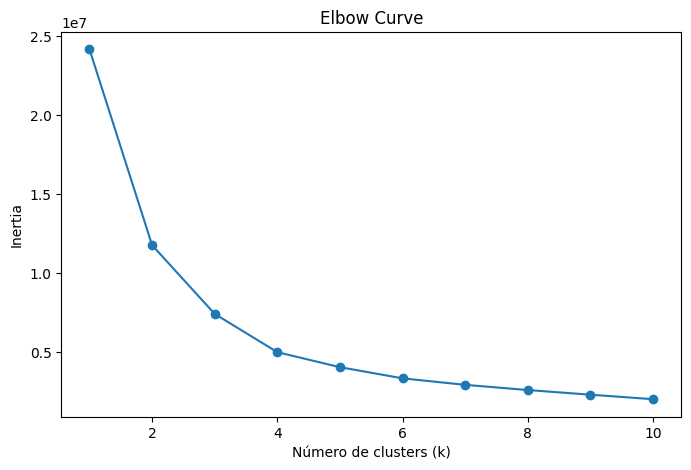

In [41]:
# Calculamos la inertia para distintos valores de k, para localizar el "codo"
# donde añadir más clusters deja de aportar una reducción significativa.
inertias = []
rango_k = range(1, 11)

for k in rango_k:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(datos_escalados)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(rango_k, inertias, marker='o')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Curve')
plt.show()

## Entrenamiento K-means

In [42]:
# Entrenamos el K-Means final con k=4, elegido por el codo de la elbow curve
# (cambio de pendiente claro entre k=3 y k=4, curva plana después).
kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)
df['cluster'] = kmeans_final.fit_predict(datos_escalados)

df['cluster'].value_counts().sort_index()

,count
cluster,
0,875697
1,20014
2,27999
3,60904


In [43]:
# Vemos el perfil medio de cada cluster en las variables originales,
# para entender qué caracteriza a cada grupo (especialmente al cluster 0, tan grande).
df.groupby('cluster')[['edad', 'CustAccountBalance', 'TransactionAmount (INR)']].median()

,edad,CustAccountBalance,TransactionAmount (INR)
cluster,,,
0,28.0,12966.83,371.0
1,37.0,1397274.65,1296.0
2,32.0,43531.05,12564.0
3,33.0,360306.88,873.0


## Perfilado de clusters - ficha de cliente

In [47]:
# Construimos la ficha de cliente con unstack() para que género y ciudad
# queden como columnas separadas, alineadas correctamente con cada cluster.

ficha_numerica = df.groupby('cluster')[
    ['edad', 'CustAccountBalance', 'TransactionAmount (INR)']
].median()

ficha_tamano = df.groupby('cluster').size().rename('n_clientes')
ficha_tamano_pct = (ficha_tamano / len(df) * 100).round(2).rename('pct_clientes')

# unstack() convierte cada categoría de género en una columna propia
ficha_genero = (
    df.groupby('cluster')['CustGender']
    .value_counts(normalize=True)
    .round(2)
    .unstack()
    .add_prefix('genero_')
)

# Igual para las 3 ciudades más frecuentes por cluster
ficha_ciudad = (
    df.groupby('cluster')['ciudad_agrupada']
    .value_counts(normalize=True)
    .round(2)
    .groupby('cluster')
    .head(3)
    .unstack()
)

ficha_cliente = pd.concat(
    [ficha_tamano, ficha_tamano_pct, ficha_numerica, ficha_genero, ficha_ciudad],
    axis=1
)

ficha_cliente

,n_clientes,pct_clientes,edad,CustAccountBalance,TransactionAmount (INR),genero_F,genero_M,OTRAS,MUMBAI,BANGALORE,NEW DELHI
cluster,,,,,,,,,,,
0,875697,88.94,28.0,12966.83,371.0,0.27,0.73,0.38,0.09,0.08,NaN
1,20014,2.03,37.0,1397274.65,1296.0,0.23,0.77,0.26,0.17,NaN,0.14
2,27999,2.84,32.0,43531.05,12564.0,0.31,0.69,0.38,0.10,NaN,0.09
3,60904,6.19,33.0,360306.88,873.0,0.31,0.69,0.28,0.14,NaN,0.12


## Visualizacon de Clusters

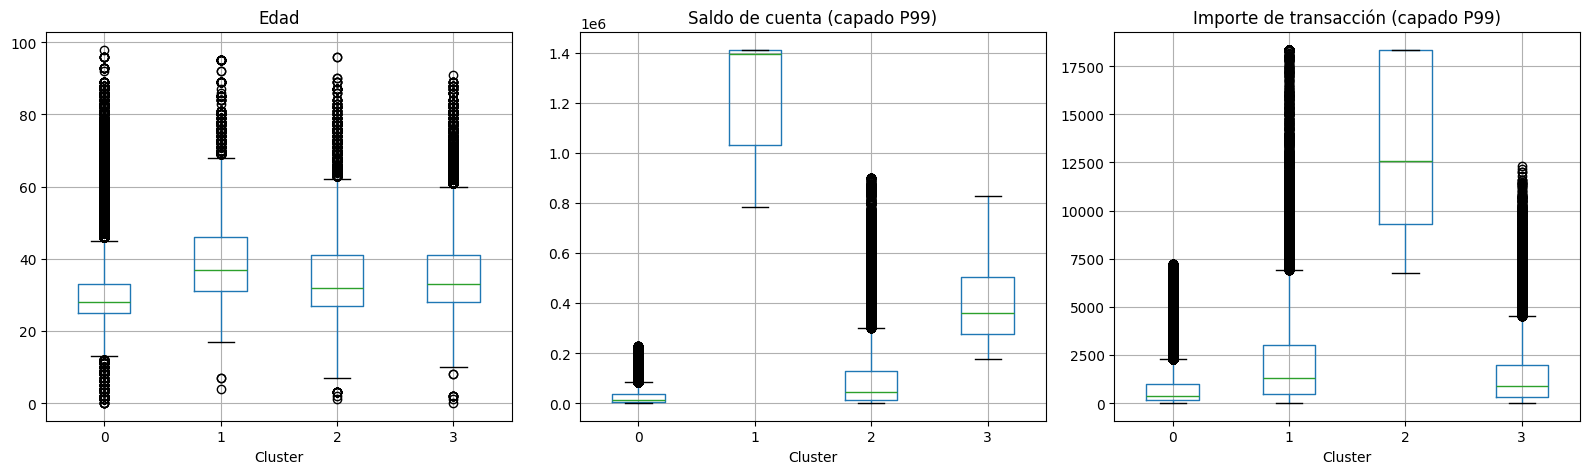

In [49]:
# Visualizamos los boxplots con las versiones capadas de saldo y gasto (mismo
# tratamiento que usamos para el modelo), para poder ver y comparar el cuerpo
# de la distribución de cada cluster sin que los outliers extremos aplasten la escala.
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

variables = ['edad', 'saldo_capado', 'gasto_capado']
titulos = ['Edad', 'Saldo de cuenta (capado P99)', 'Importe de transacción (capado P99)']

for ax, var, titulo in zip(axes, variables, titulos):
    df.boxplot(column=var, by='cluster', ax=ax)
    ax.set_title(titulo)
    ax.set_xlabel('Cluster')

plt.suptitle('')
plt.tight_layout()
plt.show()

## Outputs - guardado

In [50]:
import joblib

# Guardamos el scaler y el modelo K-Means entrenados como demostración de buena
# práctica (guardado de artefactos reutilizables), aunque este proyecto es un
# análisis de una foto fija de 2016, no un modelo en producción con datos nuevos.
joblib.dump(scaler, f"{DATA_PATH.replace('/datasets', '/outputs')}/scaler_robusto.pkl")
joblib.dump(kmeans_final, f"{DATA_PATH.replace('/datasets', '/outputs')}/kmeans_k4.pkl")

print("Artefactos guardados en la carpeta outputs/")

Artefactos guardados en la carpeta outputs/


# CONCLUSIONES

**Resultado:** segmentación de clientes de banca en 4 grupos con perfiles
socioeconómicos claramente diferenciados y validados visualmente:

- **Cluster 0 — Retail de masa (88,9%)**: edad 28, saldo bajo (13K),
  gasto contenido. Estrategia: fidelización y campaña de ahorro.
- **Cluster 1 — Alto patrimonio (2,0%)**: edad 37, saldo muy alto (1,4M),
  concentrado en Mumbai. Estrategia: banca privada.
- **Cluster 2 — Gasto puntual alto (2,8%)**: edad 32, saldo moderado,
  gasto muy elevado (12,5K). Estrategia: medios de pago digitales.
- **Cluster 3 — Medio-alto (6,2%)**: edad 33, saldo y gasto por encima
  de la media. Estrategia: productos de inversión y tarjetas de crédito.

**Limitaciones del proyecto (importantes para interpretar los resultados):**
- El dataset original es transaccional puro, sin variables de vinculación
  bancaria (nº de productos, antigüedad, préstamos, uso de canales) — la
  segmentación resultante es de **perfil socioeconómico aproximado**, no
  de comportamiento o vinculación real con el banco.
- El 83,7% de los clientes tiene una única transacción en la ventana de
  2,5 meses del dataset, por lo que las variables de saldo/gasto
  representan una fotografía puntual, no un patrón de comportamiento
  repetido y confirmado.
- No hay datos de riesgo/impago; cualquier valoración de "bajo riesgo" por
  perfil es una hipótesis razonada, no un dato verificado.

## Sobre el modelo entrenado

Este proyecto es un **análisis exploratorio de una base de datos histórica
fija** (transacciones bancarias de agosto-octubre 2016), no un sistema en
producción. Por ese motivo:

- No se ha construido un pipeline de inferencia para clientes nuevos, ya
  que el dataset no representa un flujo continuo de datos, sino una
  fotografía puntual de un periodo cerrado.
- Se guardan igualmente el `scaler` (RobustScaler) y el modelo `KMeans`
  entrenados (`outputs/scaler_robusto.pkl`, `outputs/kmeans_k4.pkl`) como
  demostración de buena práctica de guardado de artefactos, replicable en
  un escenario real de producción si este análisis se convirtiera en un
  proceso recurrente.